In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [204]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [205]:
df=pd.read_csv('karachi_properties_v2.csv')

In [206]:
df.shape

(22652, 28)

In [207]:
df.head()

,property_name,address,location,sub_location,price,price_per_sqft,area,bedrooms,bathrooms,kitchen,floor,total_floors,parking,elevator,servant_quarters,electricity_backup,furnished,completion_year,property_type,property_age,age_category,parking_score,servant_quarter_score,area_per_bedroom,district,sub_location_type,location_score,sub_location_score
0,"Brand New, West Open","saadi town - block 7, saadi town",Scheme 33,Sector 47,22800000.0,21111.11,1080.0,4,5,1.0,NaN,2.0,3.0,0,1,1,1,2025.0,house,1.0,Relatively New,2.0,1,270.00,Karachi East,Subdivision,3.0,2.0
1,Double Storey House Available For Sale,"north nazimabad - block b, north nazimabad",North Nazimabad,North Nazimabad Block B,100000000.0,22222.22,4500.0,5,5,1.0,NaN,NaN,1.0,0,1,1,1,NaN,house,NaN,NaN,1.0,1,900.00,Karachi Central,Subdivision,4.0,3.0
2,166 Square Yard Flat For Sale In North Nazimab...,"north nazimabad - block f, north nazimabad",North Nazimabad,North Nazimabad Block F,25500000.0,17068.27,1494.0,3,3,0.0,NaN,12.0,0.0,2,0,1,0,NaN,flat,NaN,NaN,0.0,0,498.00,Karachi Central,Subdivision,4.0,3.0
3,Flat Available For Sale,"pechs block 2, pechs",Jamshed Town,Pechs,65000000.0,27049.52,2403.0,4,4,2.0,NaN,NaN,2.0,0,0,1,0,NaN,flat,NaN,NaN,2.0,0,600.75,Karachi East,Housing Society,4.0,4.0
4,North Vista 2 Bed D D Flat For Sale,"north nazimabad - block b, north nazimabad",North Nazimabad,North Nazimabad Block B,16500000.0,17295.60,954.0,2,3,0.0,NaN,NaN,0.0,0,0,0,0,NaN,flat,NaN,NaN,0.0,0,477.00,Karachi Central,Subdivision,4.0,3.0


In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22652 entries, 0 to 22651
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   property_name          22652 non-null  object 
 1   address                22652 non-null  object 
 2   location               22652 non-null  object 
 3   sub_location           20237 non-null  object 
 4   price                  22652 non-null  float64
 5   price_per_sqft         22652 non-null  float64
 6   area                   22652 non-null  float64
 7   bedrooms               22652 non-null  int64  
 8   bathrooms              22652 non-null  int64  
 9   kitchen                22620 non-null  float64
 10  floor                  3683 non-null   float64
 11  total_floors           9436 non-null   float64
 12  parking                22612 non-null  float64
 13  elevator               22652 non-null  int64  
 14  servant_quarters       22652 non-null  int64  
 15  el

In [209]:
df.shape

(22652, 28)

In [210]:
df[df.duplicated()].shape

(953, 28)

In [211]:
df[
    df['floor']
    .astype(str)
    .str.contains(r'ground\s*\+|ground plus', case=False, na=False)
]

,property_name,address,location,sub_location,price,price_per_sqft,area,bedrooms,bathrooms,kitchen,floor,total_floors,parking,elevator,servant_quarters,electricity_backup,furnished,completion_year,property_type,property_age,age_category,parking_score,servant_quarter_score,area_per_bedroom,district,sub_location_type,location_score,sub_location_score


In [212]:
df['property_name'] = df['property_name'].str.lower()
df['property_name'] = (
    df['property_name']
    .str.lower()
    .str.strip()
)

In [213]:
#filling some missing value in total floors before eda
import re

def extract_total_floors(text):
    if pd.isna(text):
        return np.nan

    text = str(text).lower()

    # ground + number
    match = re.search(r'ground\s*\+\s*(\d+)', text)
    if match:
        return int(match.group(1)) + 1

    # ground plus number
    match = re.search(r'ground\s*plus\s*(\d+)', text)
    if match:
        return int(match.group(1)) + 1

    # ground+one, ground plus one
    numbers = {
        'one': 2,
        'two': 3,
        'three': 4,
        'four': 5
    }

    for word, floor in numbers.items():
        if f'ground+{word}' in text or f'ground plus {word}' in text:
            return floor

    return np.nan

mask = df['total_floors'].isna()

df.loc[mask, 'total_floors'] = (
    df.loc[mask, 'property_name']
    .apply(extract_total_floors)
)

In [214]:
df[
    df['property_name']
    .astype(str)
    .str.contains(r'ground\s*\+|ground plus', case=False, na=False) & df['total_floors'].isnull()
][['property_name','total_floors']]

,property_name,total_floors
580,leased 120 square yards ground+half house is a...,NaN
1023,house for sale ground plus wen 4 bad dd waste ...,NaN
2757,gulshan e shamim ground plus house for sale,NaN
4239,240 sq yard | ground +one | brand new | direct...,NaN
4591,ground plus tw0 house sector z where market sc...,NaN
6858,ground plus half old house prime location,NaN
7403,80 yard ground plus half house,NaN
7972,capital cooperative society house for sale 240...,NaN
8175,direct owner meeting | brand new house 240sqyd...,NaN
8967,ground plus half 200 square yards house for sale,NaN


In [215]:
df.loc[4267, 'total_floors'] = 2
df.loc[4623, 'total_floors'] = 3
df.loc[9248, 'total_floors'] = 3
df.loc[10328, 'total_floors'] = 2
df.loc[14097, 'total_floors'] = 2
df.loc[14703, 'total_floors'] = 2
df.loc[22424, 'total_floors'] = 2

In [216]:
#dropping duplicates
df = df.drop_duplicates(
    subset=df.drop(columns=['property_name']).columns,
    keep='first'
)

In [217]:
df.shape

(20569, 28)

In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20569 entries, 0 to 22651
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   property_name          20569 non-null  object 
 1   address                20569 non-null  object 
 2   location               20569 non-null  object 
 3   sub_location           18362 non-null  object 
 4   price                  20569 non-null  float64
 5   price_per_sqft         20569 non-null  float64
 6   area                   20569 non-null  float64
 7   bedrooms               20569 non-null  int64  
 8   bathrooms              20569 non-null  int64  
 9   kitchen                20537 non-null  float64
 10  floor                  3557 non-null   float64
 11  total_floors           9337 non-null   float64
 12  parking                20534 non-null  float64
 13  elevator               20569 non-null  int64  
 14  servant_quarters       20569 non-null  int64  
 15  electri

#Property Type



,count
property_type,
flat,51.388011
house,48.611989


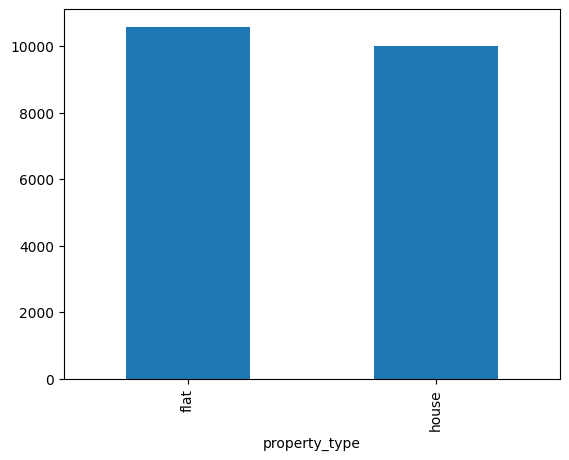

In [219]:
df['property_type'].value_counts().plot(kind='bar')
(df['property_type'].value_counts()/df.shape[0])*100

# Observation

- flats are slighly more than houses
- flats = 51%  and house = 48%
- no missing value

#Sub location


In [220]:
df[['location','sub_location']].value_counts().head(30)

location              sub_location              
DHA Defence           Phase 8                       2049
                      Phase 6                        885
Malir Cantt           Askari 5                       498
                      Askari 6                       489
Malir                 Falcon Complex New Malir       449
Gadap                 Gulshan-E-Maymar               436
Gulshan-e-Iqbal Town  Gulshan-e-Iqbal Block 10A      423
DHA Defence           Phase 5                        421
Scheme 33             Sector 35-A                    301
DHA Defence           Phase 7                        286
Jamshed Town          Pechs                          268
Scheme 33             Sector 47                      260
                      Sector 40                      236
Gadap                 Surjani Town                   216
Gulistan-e-Jauhar     Gulistan-e-Jauhar Block 15     188
North Nazimabad       North Nazimabad Block F        179
Jamshed Town          Shaheed Millat Road            173
Scheme 33             Saadi Garden                   167
Clifton               Clifton Block 2                159
DHA Defence           Phase 4                        156
Scheme 33             Punjabi Saudagar Society       147
Gulistan-e-Jauhar     Gulistan-e-Jauhar Block 14     144
Gulshan-e-Iqbal Town  Gulshan-e-Iqbal Block 1        142
DHA Defence           Phase 7 Extension              141
Gulistan-e-Jauhar     Gulistan-e-Jauhar Block 18     126
                      Gulistan-e-Jauhar Block 13     125
Karsaz                Navy Housing Scheme Karsaz     124
Clifton               Bath Island                    122
North Nazimabad       North Nazimabad Block H        122
Scheme 33             Sector 34-A                    121
Name: count, dtype: int64

In [221]:
(df['sub_location'].value_counts().head(30).sum()/df['sub_location'].value_counts().sum())*100

np.float64(52.56508005663871)

In [222]:
df['sub_location'].value_counts()

,count
sub_location,
Phase 8,2049
Phase 6,885
Askari 5,498
Askari 6,489
Falcon Complex New Malir,449
Gulshan-E-Maymar,436
Gulshan-e-Iqbal Block 10A,423
Phase 5,421
Sector 35-A,301


In [223]:
sub_counts = df['sub_location'].value_counts()
bins = [0, 25, 50, 100, 200, 500, float('inf')]

labels = [
    'Very Rare (≤25)',
    'Rare (26-50)',
    'Low (51-100)',
    'Medium (101-200)',
    'High (201-500)',
    'Very High (500+)'
]
sub_location_bins=pd.cut(
    sub_counts,
    bins=bins,
    labels=labels
)
sub_location_bins.value_counts()

,count
count,
Very Rare (≤25),81
Rare (26-50),57
Low (51-100),49
Medium (101-200),31
High (201-500),13
Very High (500+),2


<Axes: xlabel='sub_location'>

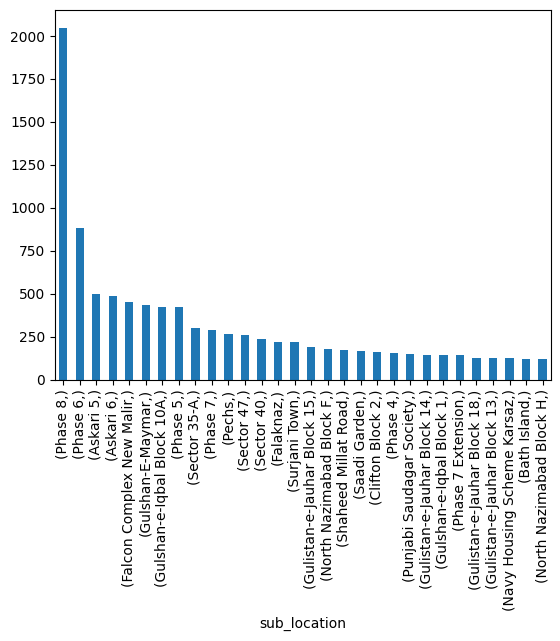

In [224]:
df[['sub_location']].value_counts().head(30).plot(kind='bar')

In [225]:
(df['sub_location'].isnull().sum()/df.shape[0])*100

np.float64(10.729738927512274)

#Observation
-  total 224 sub location

- out of 233 sub location 52.56 percent data come from top 30 sub location

  -  Very Rare (≤25)	81
  - Rare (26-50)	57
  -  Low (51-100)	49
  -  Medium (101-200)	31
  -  High (201-500)	13
  -  Very High (500+)	2
  
- 10.72 rows have missing sub location


# Location


In [226]:
df['location'].value_counts().shape

(27,)

In [227]:
print(df['location'].value_counts().head(5).sum())
(df['location'].value_counts().head(10).sum() / df.shape[0])*100

12491


np.float64(84.50580971364676)

In [228]:
df['location'].value_counts()

,count
location,
DHA Defence,4211
Scheme 33,3068
Gulshan-e-Iqbal Town,2206
Gulistan-e-Jauhar,1767
Bahria Town,1239
Malir Cantt,1145
North Nazimabad,1023
Jamshed Town,983
Malir,924


In [229]:
bins = [0, 50, 100, 250, 500, 1000, 2000, float('inf')]

labels = [
    'Very Rare (≤50)',
    'Rare (51-100)',
    'Low (101-250)',
    'Medium (251-500)',
    'High (501-1000)',
    'Very High (1001-2000)',
    'Extremely High (2000+)'
]

sub_location_bins=pd.cut(
    sub_counts,
    bins=bins,
    labels=labels
)
sub_location_bins.value_counts()

,count
count,
Very Rare (≤50),138
Rare (51-100),49
Low (101-250),34
Medium (251-500),10
High (501-1000),1
Extremely High (2000+),1
Very High (1001-2000),0


<Axes: xlabel='location'>

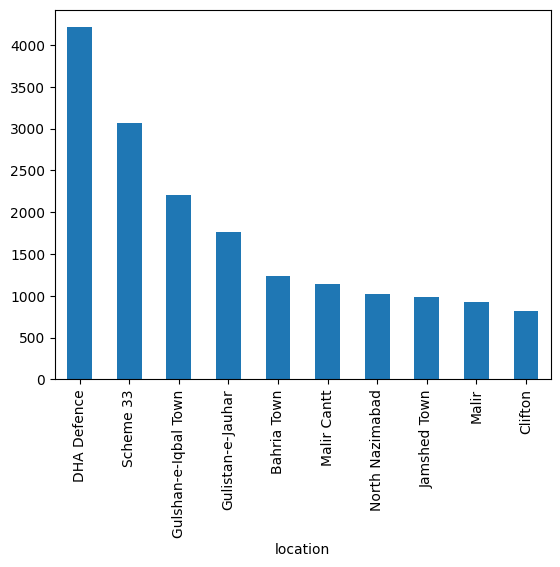

In [230]:
df['location'].value_counts().head(10).plot(kind='bar')

In [231]:
df['location'].value_counts().shape

(27,)

In [232]:
df['location'].isnull().sum()

np.int64(0)

#Observation
-  total 27 location
- out of 27 location 84 percent data come from top 10 sub location
    - Very Rare (≤50)	5
    - High (501-1000)	5
    - Rare (51-100)	4
    - Low (101-250)	4
    - Very High (1001-2000)	4
    - Extremely High (2000+)	3
    - Medium (251-500)	2
- no missing value


# District

In [233]:
df['district'].value_counts()

,count
district,
Karachi East,8111
Karachi South,5027
Malir,4155
Karachi Central,2571
Korangi,319


In [234]:
df['district'].value_counts(normalize=True)*100

,proportion
district,
Karachi East,40.187286
Karachi South,24.907100
Malir,20.586632
Karachi Central,12.738443
Korangi,1.580538


<Axes: xlabel='district'>

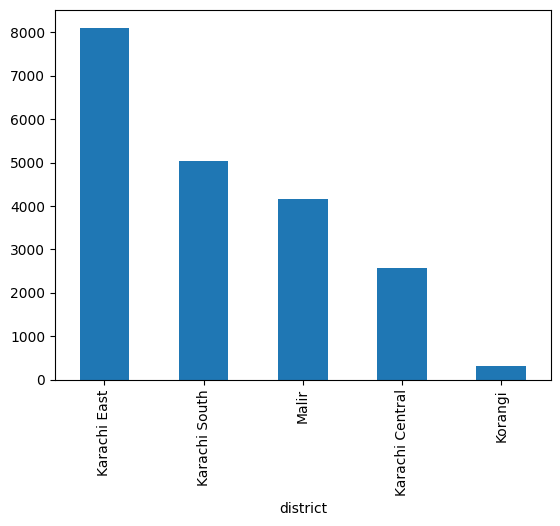

In [235]:
df['district'].value_counts().head(10).plot(kind='bar')

In [236]:
(df['district'].isnull().sum()/df['sub_location'].shape)*100

array([1.87661043])

#Observation
- majority of the houses and flats are from karachi east > karachi south > malir > karachi central > korangi
  - Karachi East	40.18%
  - Karachi South	24.90%
  - Malir	20.58%
  - Karachi Central	12.73%
  - Korangi	1.58%
- 1.87% value are missing

#Price

In [237]:
(df['price']/ 10_000_000).describe()

,price
count,20569.000000
mean,7.034798
std,10.085230
min,0.150000
25%,1.800000
50%,3.800000
75%,8.190000
max,216.000000


<Axes: xlabel='price', ylabel='Count'>

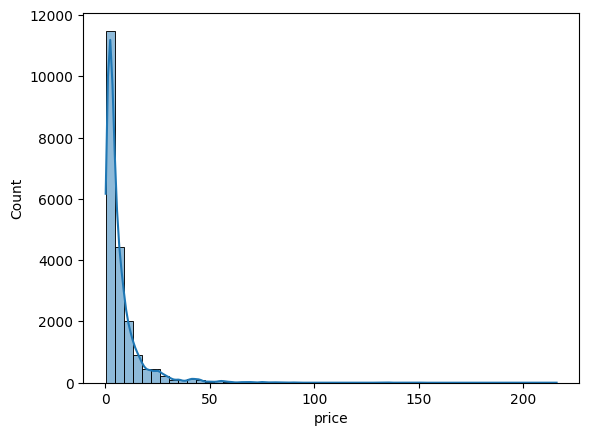

In [238]:
sns.histplot(df['price']/10_000_000,kde=True,bins=50)

<Axes: xlabel='price'>

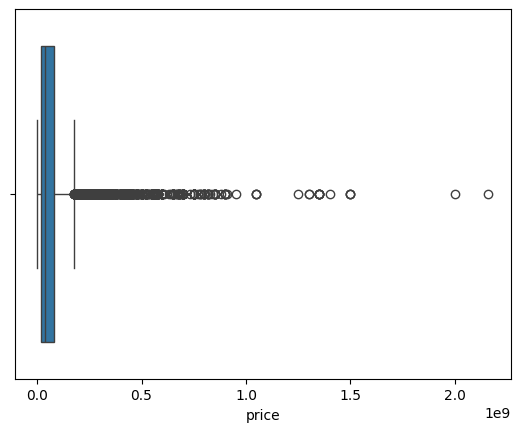

In [239]:
sns.boxplot(x=df['price'])

### Descriptive analysis of `price`

**Count:** 20,569 -> Number of property records in the dataset.

**Mean:** 7.03 crore -> Average property price.

**Std:** 10.09 crore -> Shows that property prices have high variation.

**Minimum:** 0.15 crore -> Lowest property price is 15 lakh.

**25% (Q1):** 1.80 crore -> 25% of properties have a price of 1.80 crore or less.

**50% (Median):** 3.80 crore -> 50% of properties have a price of 3.80 crore or less.

**75% (Q3):** 8.19 crore -> 75% of properties have a price of 8.19 crore or less.

**Maximum:** 216 crore -> Highest property price is 216 crore.

### Visualization
  - **Distribution**: The distribution is heavily right-skewed, with most property prices concentrated near the lower end (under 25) and a long tail extending toward higher values.

  - **Outlier** : The data contains significant extreme outliers, with high value properties stretching far beyond the upper whisker past 200.

In [240]:
#skewness and kurtosis
skewness=df['price'].skew()
kurtosis=df['price'].kurtosis()
print(skewness,kurtosis)

5.077352881867623 46.7783506462155


- **Skewness (5.08)**: Most properties are relatively affordable, but a handful of ultra-expensive luxury homes push the overall average price much higher.

- **Kurtosis (46.78)**: Property prices mostly stick to a standard, predictable range, but there are a few extreme prices that spike far above everything else.

In [241]:
(df['price']/10_000_000).quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,price
0.10,1.10
0.25,1.80
0.50,3.80
0.75,8.19
0.90,15.50
0.95,25.00
0.99,50.00


* **Middle Market (10% to 75%):** Most properties (75%) are priced under **8.19 crore**, with typical mid-range homes falling between **1.80 crore** and **8.19 crore**.

* **Budget Market (Bottom 10%):** The cheapest 10% of listings stay below **1.10 crore**.

* **Luxury Market (Top 10%):** Prices jump fast at the high end starting at **15.50 crore** (90th percentile), doubling to **25 crore** (95th percentile), and hitting **50 crore** for the top 1%.

* **Main Takeaway:** Extreme luxury properties drag the mathematical average up, making the median price (**3.80 crore**) a much truer estimate of an average home's cost.

In [242]:
## Identify potential outliers using IQR method
Q1=df['price'].describe()['25%']
Q3=df['price'].describe()['75%']
IQR=Q3-Q1


In [243]:
lower_bound=Q1 - 1.5*IQR
upper_bound=Q3 + 1.5*IQR

print(lower_bound, upper_bound)

-77850000.0 177750000.0


In [244]:
outliers=df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(1697, 28)

In [245]:
(outliers['price']/10_000_000).describe()

,price
count,1697.000000
mean,32.792664
std,18.417529
min,17.800000
25%,22.000000
50%,26.000000
75%,40.000000
max,216.000000


Outliers Analysis (using IQR method):
  - Based on the IQR method, there are 1697 properties considered as outliers.
  - These outliers have an average price of approximately 32 crores.
  - The range for these outliers is from 17.8 crores to 216 crores.

<Axes: xlabel='price'>

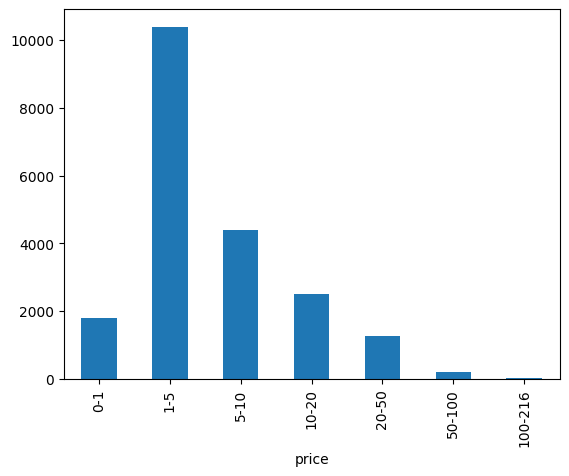

In [246]:
bins=[0,1,5,10,20,50,100,250]
bins_labels=["0-1","1-5","5-10","10-20","20-50","50-100","100-216"]
pd.cut((df['price']/10_000_000),bins=bins,labels=bins_labels,right=False).value_counts().sort_index().plot(kind='bar')

* **Most Common (1 to 5 Crore):** Over 10,000 properties cost **1 to 5 crore**.
* **Mid-Range (5 to 20 Crore):** About 7,000 properties cost **5 to 20 crore**.
* **Rare Luxury (20+ Crore):** Very few properties go above **20 crore**.
* **Main Takeaway:** Most homes stay under **10 crore**, so anything above **17.8 crore** is a rare price outlier

In [247]:
#ecdf plot
ecdf=df['price'].value_counts().sort_index().cumsum()

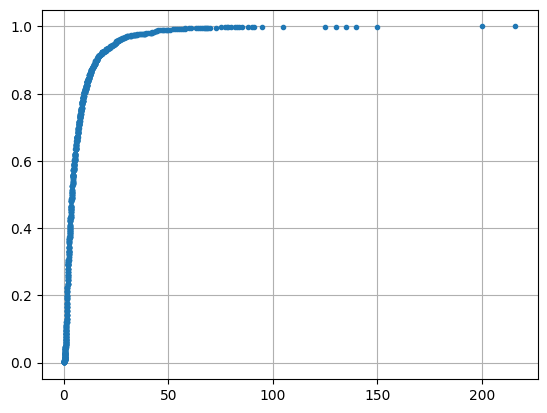

In [248]:
ecdf = (df['price']/10_000_000).value_counts().sort_index().cumsum() / len(df['price'])

plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.grid()
plt.show()

#Price per sqft


In [249]:
df['price_per_sqft'].describe()

,price_per_sqft
count,20569.000000
mean,24895.179228
std,16163.356938
min,70.660000
25%,13425.930000
50%,21394.060000
75%,31799.480000
max,612535.610000


## Descriptive Analysis
* **Core Price Range (25% to 75%):** Most properties cost between **13,426** and **31,799 PKR/sqft**.

* **Middle Price (Median):** A typical property costs **21,394 PKR/sqft**.

* **Average vs. Middle:** The average price (**24,895 PKR/sqft**) is higher than the middle price because a few expensive listings pull it up.

* **Extreme Outliers:** Prices range from as low as **70 PKR/sqft** to a massive **612,535 PKR/sqft**, showing clear data entry errors or extreme luxury listings that need cleaning.

<Axes: xlabel='price_per_sqft', ylabel='Count'>

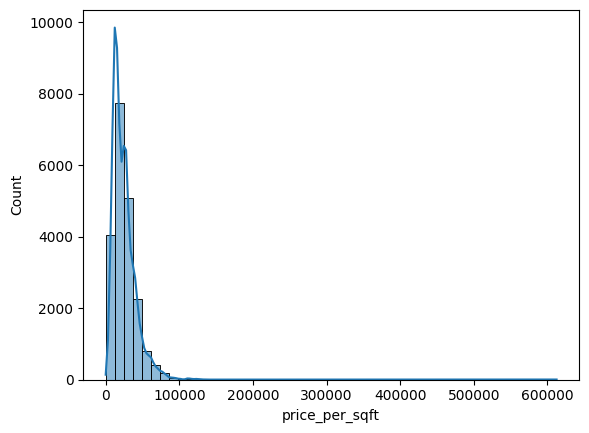

In [250]:
sns.histplot(df['price_per_sqft'],kde=True,bins=50)

<Axes: xlabel='price_per_sqft'>

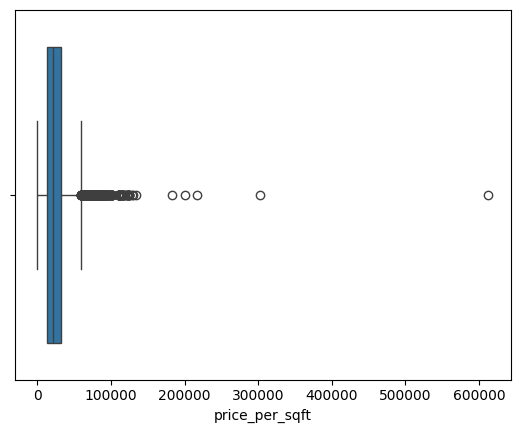

In [251]:
sns.boxplot(x=df['price_per_sqft'])

# Visualization
* Almost all properties are squished into the far left box because standard per-sqft prices are tightly clustered.

* A long horizontal line of individual dots stretches to the right, showing extreme outliers up to **600,000+ PKR/sqft**.

* A few massive data errors or extreme luxury listings stretch the axis, hiding the visual detail of regular properties.

#Bedrooms

<Axes: xlabel='bedrooms'>

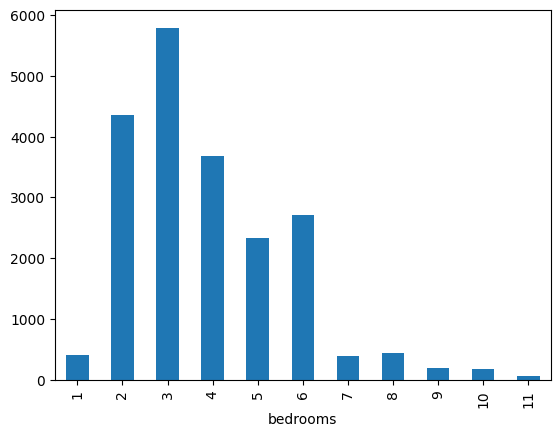

In [252]:
df['bedrooms'].value_counts().sort_index().plot(kind='bar')

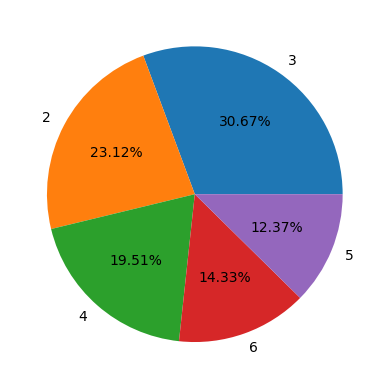

In [253]:
plt.pie(df['bedrooms'].value_counts().head(),labels=df['bedrooms'].value_counts().head().index,autopct='%0.2f%%')
plt.show()


In [254]:
df['bedrooms'].value_counts().index

Index([3, 2, 4, 6, 5, 8, 1, 7, 9, 10, 11], dtype='int64', name='bedrooms')

In [255]:
df['bathrooms'].isnull().sum()

np.int64(0)

#Observation

* 3 bedroom properties take the largest market share at **30.67%**, making them the most popular choice.
* 2, 3, and 4-bedroom listings dominate the dataset, accounting for **over 73%** of all homes.
* 5 and 6-bedroom properties make up **around 27%** of the listings, catering to larger or joint families.
* 1-bedroom units are very scarce at **just ~2%**, showing minimal market supply or demand for tiny flats.
* Listings with 7 to 11 bedrooms are extreme outliers representing large multi-unit compounds or luxury mansions.

#Bathrooms

<Axes: xlabel='bathrooms'>

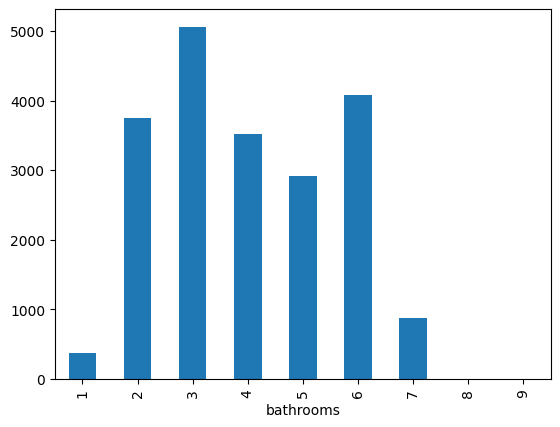

In [256]:
df['bathrooms'].value_counts().sort_index().plot(kind='bar')

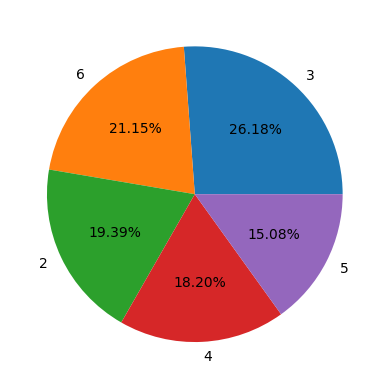

In [257]:
plt.pie(df['bathrooms'].value_counts().head(),labels=df['bathrooms'].value_counts().head().index,autopct='%0.2f%%')
plt.show()


In [258]:
df['bathrooms'].isnull().sum()

np.int64(0)

#Observastion
* 3 bathrooms form the most common layout, closely followed by 6 and 2 bathrooms.
* Properties with 2 to 6 bathrooms dominate the dataset, covering almost the entire market.
* Single-bathroom properties are very rare, matching the low percentage of 1-bedroom apartments.
* Listings with 7 or more bathrooms are extreme high-end outliers corresponding to massive houses or mansions.

# Kitchen

<Axes: xlabel='kitchen'>

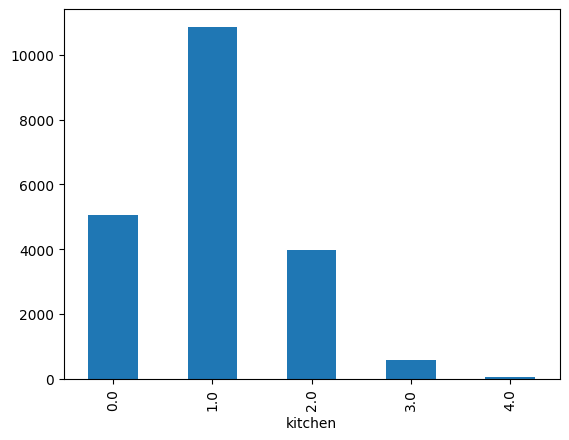

In [259]:
df['kitchen'].value_counts().sort_index().plot(kind='bar')

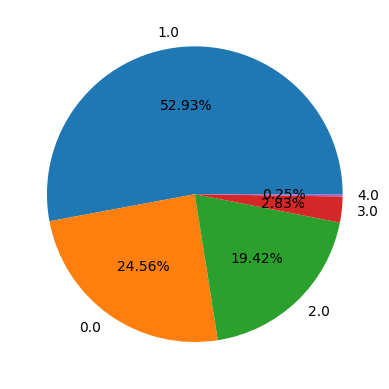

In [260]:
plt.pie(df['kitchen'].value_counts().head(),labels=df['kitchen'].value_counts().head().index,autopct='%0.2f%%')
plt.show()


In [261]:
df['kitchen'].isnull().sum()

np.int64(32)

#Observation

* 1 kitchen is the most dominant layout, accounting for more than half of all properties (**52.93%**).
* Properties with 0 reported kitchens make up almost a quarter of the listings (**24.56%**), likely indicating missing data or unequipped units.
* 2 kitchens represent nearly a fifth of the market (**19.42%**), catering primarily to multi-unit or double-story family homes.
* Listings with 3 or 4 kitchens are very rare (combining for less than **3%**), representing large multi-family or luxury properties.
* Missing kitchen records are minimal across the dataset, with only **32 missing values**.

#Floor

In [262]:
df['floor'].isnull().sum()

np.int64(17012)

In [263]:
df['floor'].describe()

,floor
count,3557.000000
mean,5.697779
std,5.649246
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,40.000000


<Axes: xlabel='floor'>

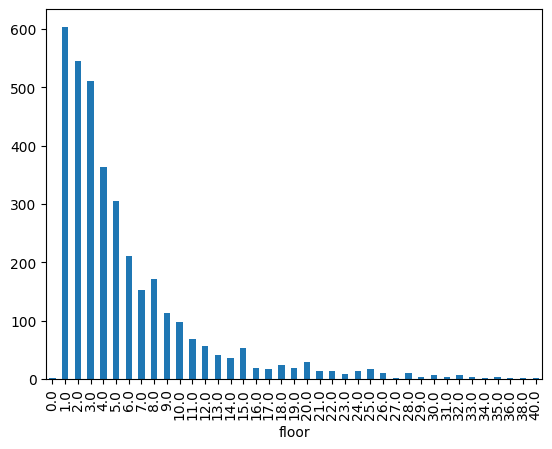

In [264]:
df['floor'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='floor'>

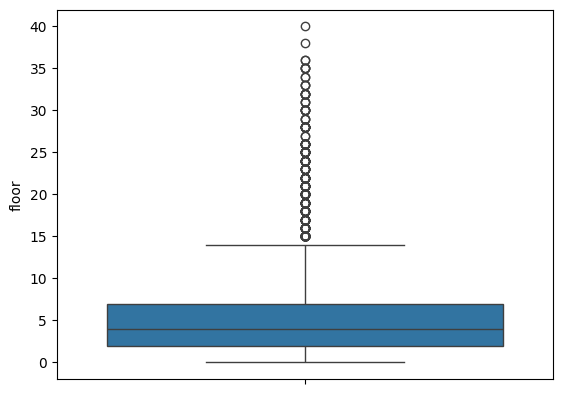

In [265]:
sns.boxplot(df['floor'])

#Observation
* A huge portion of the dataset has missing values, with **17,012 missing entries** out of 20,569 rows (~82.7% missing).
* Lower floors are the most common, with the 1st, 2nd, and 3rd floors appearing most frequently in the distribution.
* Half of the recorded properties sit between the 2nd floor ($25^{\text{th}}$ percentile) and the 7th floor ($75^{\text{th}}$ percentile), with a median of 4.
* Higher floor listings taper off quickly, though extreme values reach up to floor 40 as visible in the outlier points above the boxplot.

# total floors

In [266]:
df['total_floors'].value_counts().sort_index()

,count
total_floors,
0.0,1
1.0,842
2.0,3311
3.0,819
4.0,776
5.0,378
6.0,180
7.0,180
8.0,163


In [267]:
df['total_floors'].describe()

,total_floors
count,9337.000000
mean,8.033523
std,26.313613
min,0.000000
25%,2.000000
50%,3.000000
75%,10.000000
max,2021.000000


<Axes: xlabel='total_floors', ylabel='Count'>

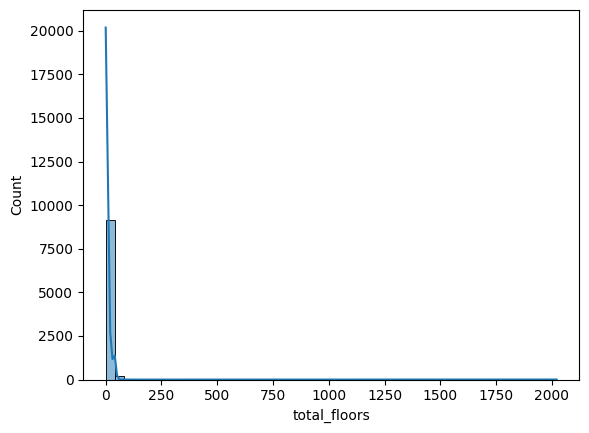

In [268]:
sns.histplot(df['total_floors'],kde=True,bins=50)

<Axes: ylabel='total_floors'>

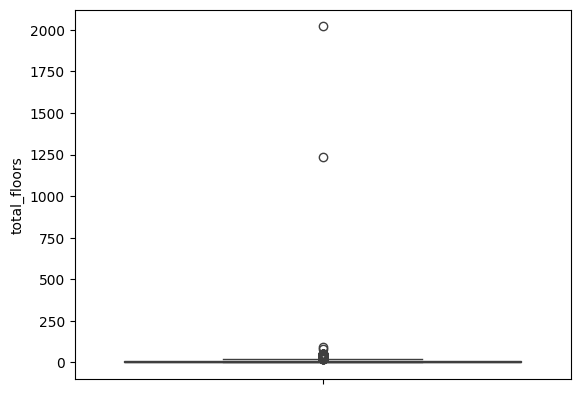

In [269]:
sns.boxplot(df['total_floors'])

#Observation
* More than half of the data is missing, with **11,232 missing rows** out of 20,569 (~54.6% missing).
* Low-rise buildings are the most common, with **2-floor** and **4-floor** buildings showing up most often.
* Half of the properties are in buildings with between **2 and 10 total floors**, with a middle value (median) of **6 floors**.
* The number of properties drops off quickly for taller buildings, though extreme high-rises stretch all the way up to **90 total floors** on the plot.

#age_category

In [270]:
df['age_category'].isnull().sum()


np.int64(9694)

In [271]:
df['age_category'].value_counts()

,count
age_category,
Relatively New,5177
New,1870
Old,1749
Moderately Old,1486
Under Construction,593


#Area

In [272]:
df['area'].isnull().sum()

np.int64(0)

In [273]:
df['area'].describe()

,area
count,20569.000000
mean,2403.750839
std,2280.086190
min,90.000000
25%,1080.000000
50%,1800.000000
75%,2799.000000
max,107550.000000


<Axes: xlabel='area', ylabel='Count'>

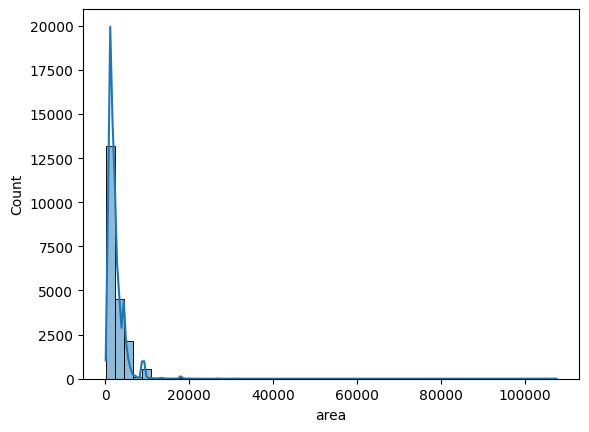

In [274]:
sns.histplot(df['area'],kde=True,bins=50)

<Axes: ylabel='area'>

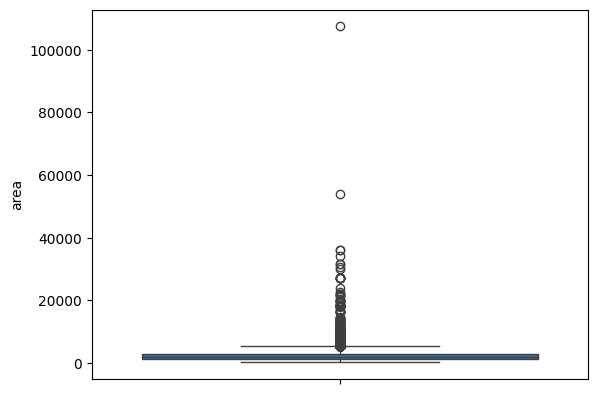

In [275]:
sns.boxplot(df['area'])

* No missing values exist in the area column.
* Most property sizes fall between **1,080 sqft** and **2,700 sqft**, with the middle value sitting at **1,800 sqft**.
* The average size is **2,400 sqft**, which is higher than the middle value because a few huge properties push the average up.
* Property sizes range from tiny **90 sqft** units up to a massive **107,550 sqft** listing.
* The huge **107,550 sqft** listing stands out as a clear outlier on the chart and should be filtered out before further modeling.

# area per bedroom

In [276]:
df['area_per_bedroom'].isnull().sum()

np.int64(0)

In [277]:
df['area_per_bedroom'].describe()

,area_per_bedroom
count,20569.000000
mean,613.786604
std,555.820344
min,33.000000
25%,400.500000
50%,540.000000
75%,749.250000
max,53775.000000


# Observation

* No missing values exist in the `area_per_bedroom` column.
* Most properties offer between **400 sqft** and **765 sqft** per bedroom, with the middle value sitting at **540 sqft**.
* The average area per bedroom is **613.79 sqft**, which is higher than the middle value because larger listings pull the average up.
* Values range from a minimum of **22.5 sqft** up to a massive **53,775 sqft** per bedroom.
* Extreme high-end values stretch far above the normal range as visible on the plot, representing clear outliers in space allocation per room.

# Parking score
 - Parking Score (0: None, 1: 1 Spot, 2: 2+ Spots)

In [278]:
df['parking_score'].isnull().sum()

np.int64(35)

In [279]:
df['parking_score'].value_counts()

,count
parking_score,
1.0,8588
0.0,6420
2.0,5526


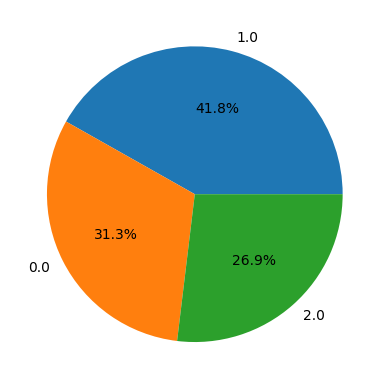

In [280]:
plt.pie(df['parking_score'].value_counts(),labels=df['parking_score'].value_counts().index,autopct='%0.1f%%')
plt.show()

* Only **35 missing values** exist in the `parking_score` column out of 20,569 total listings.
* Single-parking spaces ( score **1.0** ) make up the largest share at **41.8%** (8,588 properties).
* Properties with no designated parking space ( score **0.0** ) represent **31.3%** of the dataset (6,420 properties).
* Multiple-parking options ( score **2.0** for 2+ spaces ) account for **26.9%** of listings (5,526 properties).
* Nearly **68.7%** of all listed properties offer at least one designated parking spot.

# servant quarter score

#servant quarter score (0: None, 1: 1 Spot, 2: 2+ Spots)

In [281]:
df['servant_quarter_score'].isnull().sum()

np.int64(0)

In [282]:
df['servant_quarter_score'].value_counts()

,count
servant_quarter_score,
0,9909
1,8914
2,1746


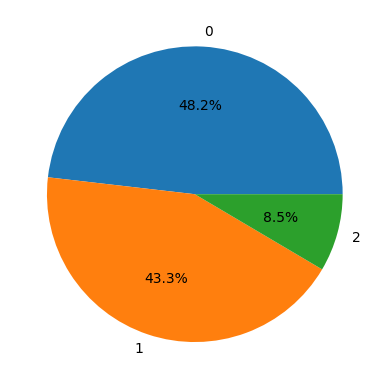

In [283]:
plt.pie(df['servant_quarter_score'].value_counts(),labels=df['servant_quarter_score'].value_counts().index,autopct='%0.1f%%')
plt.show()

#Observation

* No missing values exist in the `servant_quarter_score` column.
* Almost half of the properties (**48.2%**) have no servant quarters (score **0**), making up 9,909 listings.
* Properties with a single servant quarter (score **1**) account for **43.3%** of the dataset, representing 8,914 listings.
* Multiple servant quarters (score **2**) are relatively uncommon, covering just **8.5%** of listings (1,746 properties).
* Over half of all listed homes (**51.8%**) feature at least one servant quarter available.

# location score

- Location Score (1: Low-Value, 2: Below-Average, 3: Average, 4: Desirable, 5: Premium)

In [284]:
df['location_score'].isnull().sum()

np.int64(349)

In [285]:
df['location_score'].value_counts()

,count
location_score,
3.0,8747
5.0,6934
4.0,3373
2.0,970
1.0,196


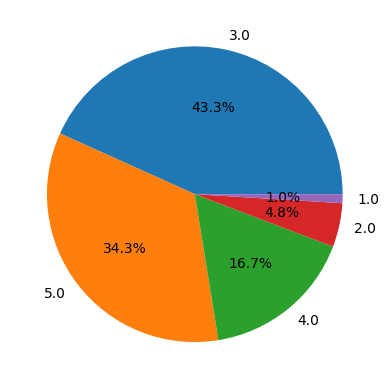

In [286]:
plt.pie(df['location_score'].value_counts(),labels=df['location_score'].value_counts().index,autopct='%0.1f%%')
plt.show()

#Observation

* No missing values exist in the `location_score` column (**0 missing values**).
* Average locations (**3.0**) form the largest group, making up **43.3%** of all listings (8,747 properties).
* Premium locations (**5.0**) represent the second-largest share at **34.3%** of the dataset (6,934 properties).
* Desirable locations (**4.0**) account for **16.7%** of listed properties (3,373 properties).
* Below-average locations (**2.0**) are uncommon at **4.8%** (970 properties).
* Low-value locations (**1.0**) are rare, representing just **1.0%** of total listings (196 properties).

# sub location score

- Location Score (1: Low-Value, 2: Below-Average, 3: Average, 4: Desirable, 5: Premium)

In [287]:
df['sub_location_score'].isnull().sum()

np.int64(2207)

In [288]:
df['sub_location_score'].value_counts()

,count
sub_location_score,
5.0,4086
3.0,3794
2.0,3654
4.0,3425
1.0,3403


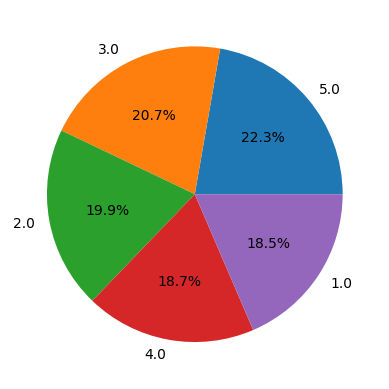

In [289]:
plt.pie(df['sub_location_score'].value_counts(),labels=df['sub_location_score'].value_counts().index,autopct='%0.1f%%')
plt.show()

# Observation

* **2,207 missing values** exist in the `sub_location_score` column (~10.7% missing).
* Distribution across all score tiers is remarkably balanced, with each score making up roughly **18% to 22%** of non-missing listings.
* Premium sub-locations (**5.0**) form the largest segment at **22.3%** (4,086 properties).
* Average sub-locations (**3.0**) follow closely with **20.7%** (3,794 properties).
* Below-average sub-locations (**2.0**) account for **19.9%** (3,654 properties).
* Desirable sub-locations (**4.0**) represent **18.7%** (3,425 properties).
* Low-value sub-locations (**1.0**) make up **18.5%** (3,403 properties).

# sub location type

- Location Score (1: Low-Value, 2: Below-Average, 3: Average, 4: Desirable, 5: Premium)

In [290]:
df['sub_location_type'].isnull().sum()

np.int64(2207)

In [291]:
df['sub_location_type'].value_counts()

,count
sub_location_type,
Subdivision,12610
Neighbourhood,1837
Residential Project,1245
Military Housing,1194
Housing Society,960
Road,516


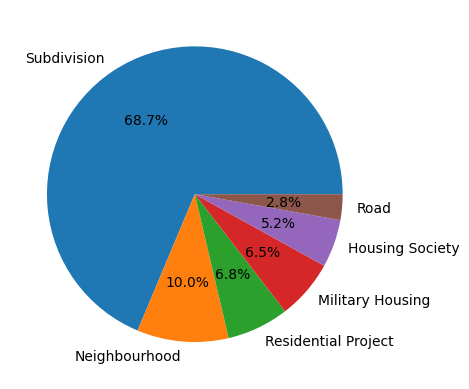

In [292]:
plt.pie(df['sub_location_type'].value_counts(),labels=df['sub_location_type'].value_counts().index,autopct='%0.1f%%')
plt.show()

# Observation
* **2,207 missing values** exist in the `sub_location_type` column (~10.7% missing).
* **Subdivision** dominates the dataset, accounting for **68.7%** of non-missing listings (12,610 properties).
* **Neighbourhood** makes up **10.0%** of listings (1,837 properties).
* **Residential Project** represents **6.8%** of the dataset (1,245 properties).
* **Military Housing** accounts for **6.5%** of properties (1,194 listings).
* **Housing Society** covers **5.2%** of listings (960 properties).
* **Road** is the smallest category, representing just **2.8%** of total listings (516 properties).

In [293]:
df.head()

,property_name,address,location,sub_location,price,price_per_sqft,area,bedrooms,bathrooms,kitchen,floor,total_floors,parking,elevator,servant_quarters,electricity_backup,furnished,completion_year,property_type,property_age,age_category,parking_score,servant_quarter_score,area_per_bedroom,district,sub_location_type,location_score,sub_location_score
0,"brand new, west open","saadi town - block 7, saadi town",Scheme 33,Sector 47,22800000.0,21111.11,1080.0,4,5,1.0,NaN,2.0,3.0,0,1,1,1,2025.0,house,1.0,Relatively New,2.0,1,270.00,Karachi East,Subdivision,3.0,2.0
1,double storey house available for sale,"north nazimabad - block b, north nazimabad",North Nazimabad,North Nazimabad Block B,100000000.0,22222.22,4500.0,5,5,1.0,NaN,NaN,1.0,0,1,1,1,NaN,house,NaN,NaN,1.0,1,900.00,Karachi Central,Subdivision,4.0,3.0
2,166 square yard flat for sale in north nazimab...,"north nazimabad - block f, north nazimabad",North Nazimabad,North Nazimabad Block F,25500000.0,17068.27,1494.0,3,3,0.0,NaN,12.0,0.0,2,0,1,0,NaN,flat,NaN,NaN,0.0,0,498.00,Karachi Central,Subdivision,4.0,3.0
3,flat available for sale,"pechs block 2, pechs",Jamshed Town,Pechs,65000000.0,27049.52,2403.0,4,4,2.0,NaN,NaN,2.0,0,0,1,0,NaN,flat,NaN,NaN,2.0,0,600.75,Karachi East,Housing Society,4.0,4.0
4,north vista 2 bed d d flat for sale,"north nazimabad - block b, north nazimabad",North Nazimabad,North Nazimabad Block B,16500000.0,17295.60,954.0,2,3,0.0,NaN,NaN,0.0,0,0,0,0,NaN,flat,NaN,NaN,0.0,0,477.00,Karachi Central,Subdivision,4.0,3.0


# Electrivity Backup & furnished

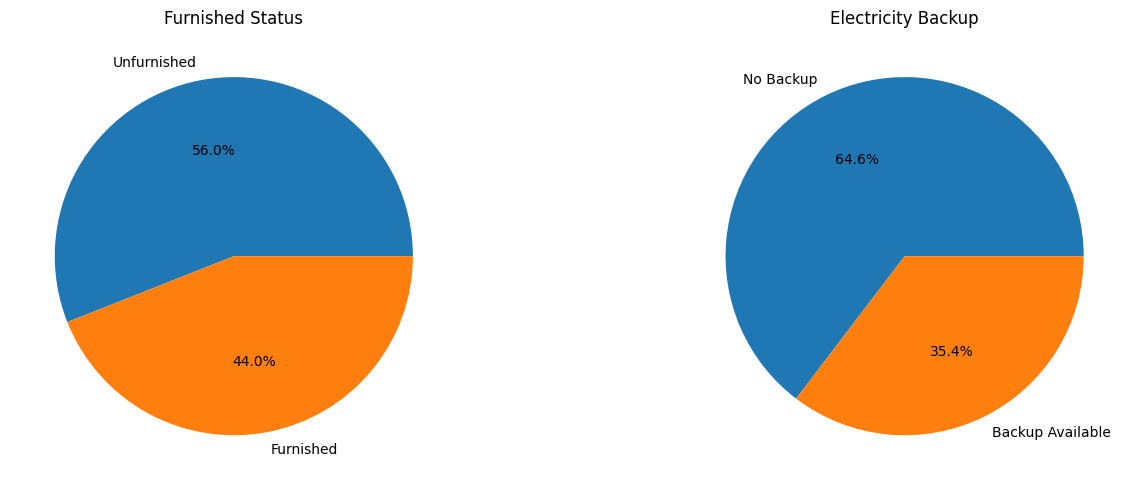

In [294]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Furnished
df['furnished'].value_counts().plot(
    kind='pie',
    ax=axes[0],
    autopct='%1.1f%%',
    labels=['Unfurnished', 'Furnished'],
    title='Furnished Status',
    ylabel='',
)

# Electricity Backup
df['electricity_backup'].value_counts().plot(
    kind='pie',
    ax=axes[1],
    autopct='%1.1f%%',
    labels=['No Backup', 'Backup Available'],
    title='Electricity Backup',
    ylabel='',
)

plt.tight_layout()
plt.show()

#Observation
* No missing values exist in the `furnished` ,`electricity_backup` columns (**0 missing values**).
* Over half of all properties (**56.0%**) are unfurnished, while **44.0%** come furnished (9,050 listings).
* Most properties (**64.6%**) lack an electricity backup, whereas **35.4%** offer power backup facilities (7,281 listings).

# Elevator


In [295]:
df['elevator'].value_counts()

,count
elevator,
0,14397
1,3154
2,1335
4,649
3,637
6,179
5,128
8,41
7,29


<Axes: xlabel='elevator', ylabel='Count'>

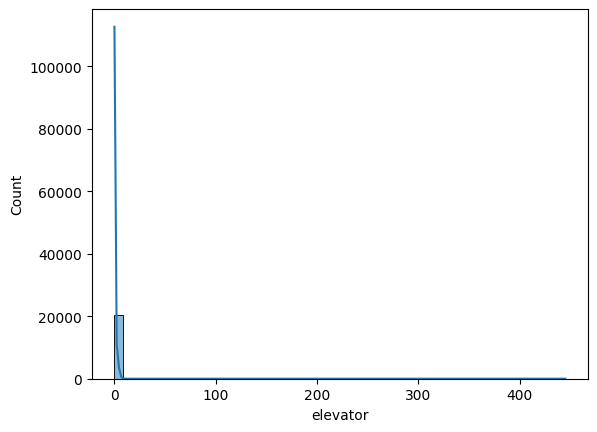

In [296]:
sns.histplot(df['elevator'],kde=True,bins=50)

<Axes: ylabel='elevator'>

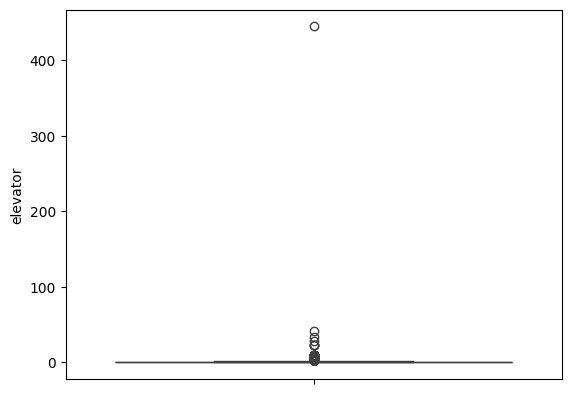

In [297]:
sns.boxplot(df['elevator'])

#observation
No missing values exist in the elevator column (0 missing values).

Properties with no elevator (0) form the vast majority at 70.0% of all listings (14,397 properties).

Properties with a single elevator (1) make up 15.3% of the dataset (3,154 properties).

Properties with 2 elevators (2) account for 6.5% of listings (1,335 properties).

Properties with 3 or 4 elevators (3 and 4) together represent 6.2% of listed properties (1,286 properties).

High-elevator counts (5 or more) are rare outliers, covering just 2.0% of total listings (397 properties).

In [298]:
df.to_csv('karachi_properties_v2.1.csv', index=False)